# Week 2 Notebook: Random Reshuffling SGD for Train and Validation Workflows


**Goal:** implement one SGD variant, random reshuffling, and compare two evaluation workflows on a fixed split.
- Workflow A: train first, then validate once at the end, producing one final validation loss.
- Workflow B: train and validate after each epoch, producing a validation loss sequence.

## Part 1: Setup and Imports

We first import required libraries and confirm the PyTorch version for reproducibility of the learning environment.

In [1]:
import copy
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
print("pytorch version:",  torch.__version__)


pytorch version: 2.2.2


## Part 2: Toy Data and Fixed Split

We generate synthetic regression data, then split it once into training and validation sets.
No hyperparameter tuning is done in this notebook: the split stays fixed throughout.

In [2]:
torch.manual_seed(0) # Reproducibility: set the random seed for torch
N = 10000
d = 6
X = torch.randn(N, d)  # Random input features of shape (N, d)
W_true =  torch.linspace(1, 10, d).reshape(d, 1)  # True weights of shape (d, 1)
b_true = torch.tensor([5.0])  # True bias of shape (1,)
# Generate target values with some noise
noise = torch.randn(N, 1) * 0.5  # Noise with standard deviation of 0.5
y = X @ W_true + b_true + noise  #

In [3]:
# Split the data into train and validation sets (validation is used as unseen-data proxy)
train_ratio = 0.8
train_size = int(N * train_ratio)
X_train, X_eval = X[:train_size], X[train_size:] # The slicing operation works in tensors just like in numpy arrays
y_train, y_eval = y[:train_size], y[train_size:]

# Backward-compatible aliases with earlier "test" naming
X_test, y_test = X_eval, y_eval

## Part 3: Model and Core Functions

In this part, we define the model and the core helpers used in both workflows.
- `train_model`: random reshuffling SGD training
- `evaluate_model`: one full validation pass
- `plot_loss`: helper visualization

In [4]:
class ShallowNN(nn.Module):
    def __init__(
            self, 
            input_dim: int =6,
            hidden_dim: int =16,
            output_dim: int =1,
            ):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.activation = nn.Tanh()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        hidden = self.fc1(x)
        z = self.activation(hidden)
        output = self.fc2(z)
        return output


In [5]:
# Define the training function using the random reshuffling sampling in the stochastic gradient descent algorithm

def train_model(
        model: nn.Module,
        X_train: torch.Tensor,
        y_train: torch.Tensor,
        loss_fn: nn.Module,
        optimizer: torch.optim.Optimizer, # here we use the gradient descent algorithm to update the model parameters
        num_epochs: int = 1000,
        batch_size: int = 32,
        track_progress: bool = True
    ):
    """
    Train a PyTorch model using the random reshuffling sampling in the stochastic gradient descent algorithm.

    Args:
        model (nn.Module): The PyTorch model to be trained.
        X_train (torch.Tensor): Training input features of shape (N, d).
        y_train (torch.Tensor): Training target values of shape (N, 1).
        loss_fn (nn.Module): Loss function to be used for training.
        optimizer (torch.optim.Optimizer): Optimizer to update the model parameters.
        num_epochs (int): Number of epochs to train the model.
        batch_size (int): Size of each mini-batch
    """

    N = X_train.shape[0]  # Number of training samples

    loss_history = []  # To store one loss value per epoch
    t = 0  # Epoch counter (consistent with epoch-level loss logging)
    model.train()  # Set the model to training mode
    for _ in range(num_epochs):
        # Randomly shuffle the training data at the beginning of each epoch
        perm = torch.randperm(N)
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]

        epoch_loss_sum = 0.0
        num_seen = 0

        for start_idx in range(0, N, batch_size):
            # Get the indices for the current mini-batch
            end_idx = start_idx + batch_size

            # Get the mini-batch data
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]

            # Forward pass: compute predicted y by passing x to the model
            y_pred = model(X_batch)

            # Compute and print loss
            loss = loss_fn(y_pred, y_batch)

            # Zero gradients, perform a backward pass, and update the weights.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            actual_batch_size = X_batch.shape[0]
            epoch_loss_sum += loss.item() * actual_batch_size
            num_seen += actual_batch_size

        # Store one averaged loss value for this epoch
        epoch_loss = epoch_loss_sum / num_seen
        loss_history.append(epoch_loss)
        t += 1
        if track_progress and t % 10 == 0:
            print(f"Epoch {t}/{num_epochs}, Loss: {epoch_loss:.4f}")

    return loss_history

In [6]:
# Workflow A helper: evaluate once after training is complete.
# This computes one final validation loss on the full validation set (no mini-batches).


def evaluate_model(
        model: nn.Module,
        X_eval: torch.Tensor,
        y_eval: torch.Tensor,
        loss_fn: nn.Module
    ):
    """
    Evaluate a trained PyTorch model for Workflow A (single end-of-training validation pass).

    Args:
        model (nn.Module): The PyTorch model to be evaluated.
        X_eval (torch.Tensor): Validation input features of shape (N, d).
        y_eval (torch.Tensor): Validation target values of shape (N, 1).
        loss_fn (nn.Module): Loss function to be used for evaluation.

    Returns:
        float: The computed loss on the validation set.
    """
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():  # Disable gradient computation for evaluation to avoid unnecessary memory usage and improve performance during evaluation
        y_pred = model(X_eval)  # Forward pass on the entire validation set
        loss = loss_fn(y_pred, y_eval)  # Compute the loss
    return loss.item()  # Return the loss as a float


In [7]:
# Helper to plot Loss function

def plot_loss(loss_history, title="Training Loss History"):
    """
    Plot the loss function over epochs.

    Args:
        loss_history (list): List of loss values recorded during training.
        title (str): Title of the plot.
    """
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.plot(loss_history, label='Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

Implementation note for the core functions:

- `train_model()` performs parameter updates with random reshuffling SGD.
- `evaluate_model()` performs one full validation pass with `model.eval()` and `torch.no_grad()`.

This separation is useful when you want a simple workflow: train fully, then evaluate once.

Parameter-update reminder:

`train_model()` updates weights and biases in place through backpropagation and optimizer steps.
After training, calling `evaluate_model()` uses those updated parameters to compute validation loss.

## Part 4: Workflow A - Train First, Validate Once

This workflow trains with random reshuffling SGD, then runs one final validation pass.
Expected outputs:
- training loss history
- one final validation loss scalar

Initial loss: 260.53814697265625


Epoch 10/100, Loss: 0.4030
Epoch 20/100, Loss: 0.3288
Epoch 30/100, Loss: 0.3124
Epoch 40/100, Loss: 0.3016
Epoch 50/100, Loss: 0.2978
Epoch 60/100, Loss: 0.2939
Epoch 70/100, Loss: 0.2855
Epoch 80/100, Loss: 0.2875
Epoch 90/100, Loss: 0.2849
Epoch 100/100, Loss: 0.2803
Training time: 37.63 seconds


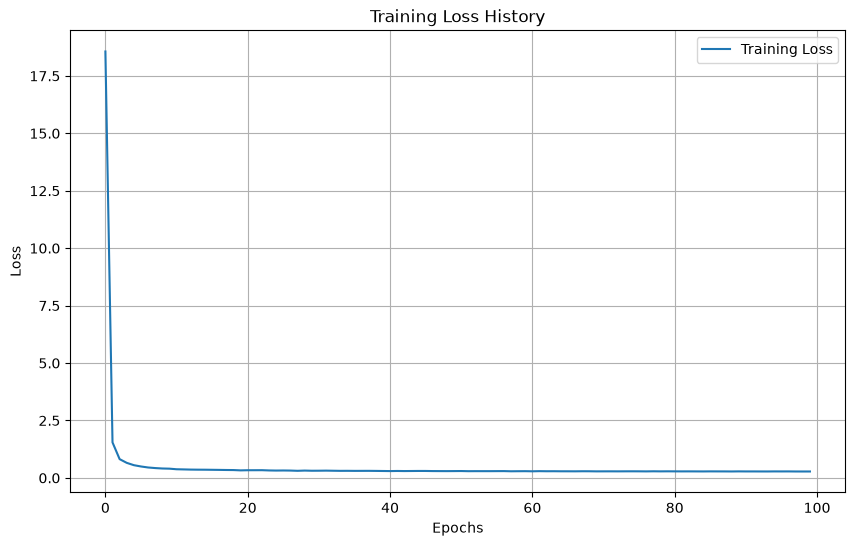

In [8]:

# 1) Fix the random seed once
torch.manual_seed(42)

# 2) Build a reference model once
reference_model = ShallowNN(input_dim=6, hidden_dim=16, output_dim=1)

# 3) Save its initial parameters
initial_state = copy.deepcopy(reference_model.state_dict())

# Check the starting loss for the reference initialization
loss_fn = nn.MSELoss()
with torch.no_grad(): # it tells PyTorch not to compute gradients for this operation
    initial_loss = loss_fn(reference_model(X), y) 
print("Initial loss:", initial_loss.item())

# 4) Taining set up using the random reshuffling gradient descent (RSGD) algorithm

lr = 0.01
n_epochs = 100
batch_size = 32
optimizer = torch.optim.SGD(reference_model.parameters(), lr=lr) # We use the initialized model parameters to start the training process. The optimizer will update these parameters during training.


# 5) Reset the random seed before Workflow A training to reproduce the same reshuffles and loss path
torch.manual_seed(42)

# 6) Start the training process and measure the time taken
start_time = time.time()

Loss_history = train_model(
    model=reference_model,
    X_train=X_train,
    y_train=y_train,
    loss_fn=loss_fn,
    optimizer=optimizer,
    num_epochs=n_epochs,
    batch_size=batch_size
)

end_time = time.time()
training_time = end_time - start_time

# Print the training time
print(f"Training time: {training_time:.2f} seconds")

# Plot the loss function 

plot_loss(Loss_history)

In [9]:
# Run the evaluation function to compute the loss on the validation set using the standard approach
test_loss = evaluate_model(
    model=reference_model,
    X_eval=X_eval,
    y_eval=y_eval,
    loss_fn=loss_fn
)
print("Test loss:", test_loss)

Test loss: 0.2808578908443451


## Part 5: Notes - Why `model.train()` and `model.eval()` both appear

`model.train()` does not visibly change the forward pass for this architecture because `Linear` and `Tanh` behave the same in both modes.

However, the mode switch is still correct practice because other layers can behave differently:

- `Dropout` randomly disables activations during training and is disabled during evaluation.
- `BatchNorm` uses batch statistics during training and running statistics during evaluation.

In this notebook, `train_model()` updates weights in place, and `evaluate_model()` reads those updated weights to compute final validation loss.

In [10]:
# At training step k, which rows of X_train and y_train should I use?

# In random reshuffling SGD, for each epoch we:

# 1) build a random permutation of row indices
perm = torch.randperm(X_train.shape[0])

# 2) read mini-batches from the shuffled tensors with contiguous slices
X_train_shuffled = X_train[perm]
y_train_shuffled = y_train[perm]

# 3) for each step k, take rows [start_idx:end_idx]
k = 0
start_idx = k * batch_size
end_idx = start_idx + batch_size
X_batch_k = X_train_shuffled[start_idx:end_idx]
y_batch_k = y_train_shuffled[start_idx:end_idx]

print("batch 0 shape:", X_batch_k.shape, y_batch_k.shape)

batch 0 shape: torch.Size([32, 6]) torch.Size([32, 1])


## Part 6: Workflow B - Train and Validate During Training

In this workflow, each epoch has two steps:
- train on shuffled mini-batches
- evaluate on the validation set

This produces an evaluation-loss sequence (not just one final scalar), which helps monitor generalization over epochs.

In [11]:
# Workflow B helper: combine training and validation in one function.
# This function trains with random reshuffling SGD and evaluates after each epoch, returning both loss histories.

def train_eval_model(
        model: nn.Module,
        X_train: torch.Tensor,
        y_train: torch.Tensor,
        X_eval: torch.Tensor,
        y_eval: torch.Tensor,
        loss_fn: nn.Module,
        optimizer: torch.optim.Optimizer,
        num_epochs: int = 1000,
        batch_size: int = 32,
        track_progress: bool = True
    ):
    """
    Train a PyTorch model and evaluate it after each epoch.

    Args:
        model (nn.Module): The PyTorch model to be trained and evaluated.
        X_train (torch.Tensor): Training input features of shape (N, d).
        y_train (torch.Tensor): Training target values of shape (N, 1).
        X_eval (torch.Tensor): Evaluation input features of shape (N, d).
        y_eval (torch.Tensor): Evaluation target values of shape (N, 1).
        loss_fn (nn.Module): Loss function to be used for training and evaluation.
        optimizer (torch.optim.Optimizer): Optimizer to update the model parameters.
        num_epochs (int): Number of epochs to train the model.
        batch_size (int): Size of each mini-batch.
    Returns:
        tuple: A tuple containing the training loss history and evaluation loss history.
    """
    
    train_loss_history = []
    eval_loss_history = []
    N = X_train.shape[0]  # Number of training samples  

    for epoch in range(num_epochs):
        # Step 1: train for one epoch using the random reshuffling sampling in the stochastic gradient descent algorithm
        model.train()  # Set the model to training mode
        # Randomly shuffle the training data at the beginning of each epoch
        perm = torch.randperm(N)
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]

        epoch_loss_sum = 0.0
        num_seen = 0
    
        for start_idx in range(0, N, batch_size):
            # Get the indices for the current mini-batch
            end_idx = start_idx + batch_size

            # Get the mini-batch data
            X_batch = X_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]

            # Forward pass: compute predicted y by passing x to the model
            y_pred = model(X_batch)

            # Compute loss
            loss = loss_fn(y_pred, y_batch)

            # Zero gradients, perform a backward pass, and update the weights.
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            actual_batch_size = X_batch.shape[0]
            epoch_loss_sum += loss.item() * actual_batch_size
            num_seen += actual_batch_size

        # Store one averaged loss value for this epoch
        epoch_loss = epoch_loss_sum / num_seen
        train_loss_history.append(epoch_loss)

        # Step 2: Evaluate the model after each epoch
        model.eval()  # Set the model to evaluation mode
        with torch.no_grad():
            y_eval_pred = model(X_eval)
            eval_loss = loss_fn(y_eval_pred, y_eval).item()
            eval_loss_history.append(eval_loss)

        if track_progress and (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch + 1}/{num_epochs}, "
                f"Train loss: {epoch_loss:.4f}, "
                f"Eval loss: {eval_loss:.4f}"
            )
            

    return train_loss_history, eval_loss_history

In [12]:
# Workflow B setup: initialize model, optimizer, and run train+validate loop

# 1) Build a fresh model instance for Workflow B
train_eval_model_instance = ShallowNN(input_dim=6, hidden_dim=16, output_dim=1)
train_eval_model_instance.load_state_dict(initial_state)

# 2) Set the optimizer configuration for Workflow B
lr = 0.01
optimizer_train_eval = torch.optim.SGD(
    train_eval_model_instance.parameters(),
    lr=lr,
)

# 3) Reset the random seed before Workflow B training to reproduce the same reshuffles and loss path
torch.manual_seed(42)

# 4) Run Workflow B training+validation and measure elapsed time
start_time = time.time()
train_loss_history, eval_loss_history = train_eval_model(
    model=train_eval_model_instance,
    X_train=X_train,
    y_train=y_train,
    X_eval=X_eval,
    y_eval=y_eval,
    loss_fn=loss_fn,
    optimizer=optimizer_train_eval,
    num_epochs=n_epochs,
    batch_size=batch_size,
)
end_time = time.time()
training_time = end_time - start_time

# Print the training time
print(f"Training time for train_eval_model: {training_time:.2f} seconds")

Epoch 10/100, Train loss: 0.4030, Eval loss: 0.3119
Epoch 20/100, Train loss: 0.3288, Eval loss: 0.3219
Epoch 30/100, Train loss: 0.3124, Eval loss: 0.3537
Epoch 40/100, Train loss: 0.3016, Eval loss: 0.3654
Epoch 50/100, Train loss: 0.2978, Eval loss: 0.2943
Epoch 60/100, Train loss: 0.2939, Eval loss: 0.2778
Epoch 70/100, Train loss: 0.2855, Eval loss: 0.3242
Epoch 80/100, Train loss: 0.2875, Eval loss: 0.2902
Epoch 90/100, Train loss: 0.2849, Eval loss: 0.2846
Epoch 100/100, Train loss: 0.2803, Eval loss: 0.2809
Training time for train_eval_model: 28.61 seconds


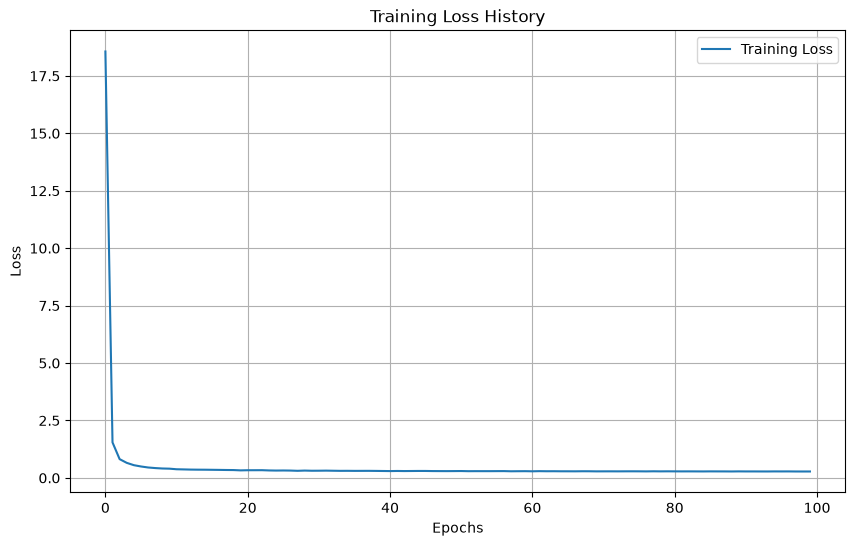

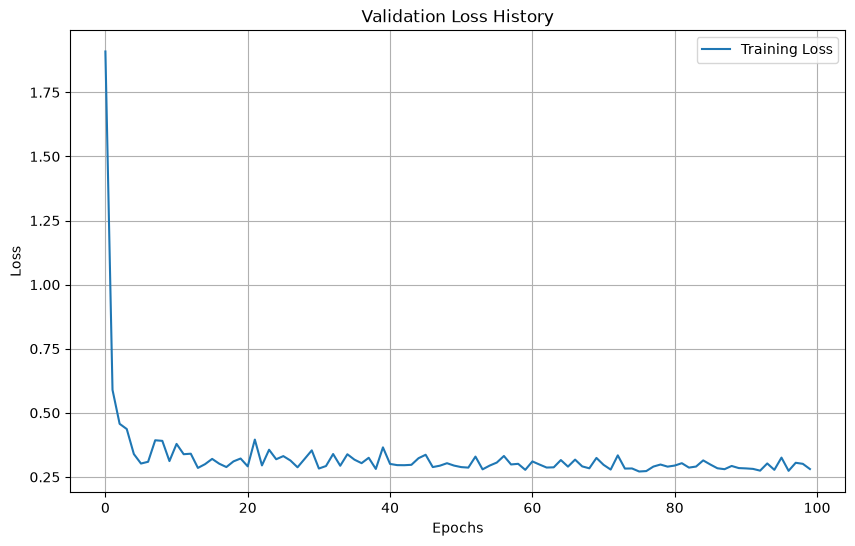

In [13]:
# plot the training and evaluation loss histories

plot_loss(train_loss_history)

plot_loss(eval_loss_history, title="Validation Loss History")

## Part 7: Comparison - Validate Once vs Validate During Training

Workflow A (train fully, evaluate once):

- Lower overhead during training.
- Produces one final validation loss.
- Suitable for simple baselines and quick checks.

Workflow B (train and evaluate every epoch):

- Higher overhead due to repeated validation passes.
- Produces an evaluation-loss sequence across epochs.
- Better visibility for overfitting and model-selection decisions.